# Implementace backpropagace pro MLP

In [1]:
# Library tqdm is a useful tool for creating progress bars
from tqdm import tqdm

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import pylab as pl

from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn import metrics

## MLP s backpropagací

In [2]:
def sigmoid(x):
    # Clip the values to prevent overflows
    x = x.clip(-5e2,5e2)
    
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)

In [3]:
class MultiLayerPerceptron:
    def __init__(self, layer_sizes, training_iterations=int(1e4), learning_rate=1e-2):
        self.layer_sizes = layer_sizes
        self.weights = []
        self.training_iterations = training_iterations
        self.learning_rate = learning_rate
        self.last_run_activations = None
        
        for (input_layer_size, output_layer_size) in zip(self.layer_sizes, self.layer_sizes[1:]):
           self.weights.append(np.random.normal(size=(input_layer_size + 1, output_layer_size)))
           
           
    def _add_ones(self, x):
        """ Add a column of ones for bias (the first row in the weight matrix represents the biases) """
        ones = np.ones(shape=(x.shape[0], 1))
        return np.concatenate([ones, x], axis=1)
    
    
    def predict(self, inputs):
        activations = np.array(inputs)
        self.last_run_activations = [activations]
        
        try:
            for layer in self.weights:
                extended_activations = self._add_ones(activations)
                linear_combination = np.dot(extended_activations, layer)
                activations = sigmoid(linear_combination)
                self.last_run_activations.append(activations)
                
        except Exception as e:
            print("Activations:", activations)
            raise e

        return activations
    
    
    def fit(self, inputs, labels):
        progress_bar = tqdm(range(self.training_iterations))
        for i in progress_bar:
            # Compute the NN's output
            self.predict(inputs)
            
            # Perform the backpropagation
            self._perform_backpropagation(labels)
            
            # Check the performance once per hundered iterations
            if i % 100 == 0:
                predictions = self.predict(inputs)
                predicted_classes = np.argmax(predictions, axis=-1)
                model_accuracy = accuracy_score(predicted_classes, labels)
                progress_bar.set_description(f"Accuracy after iteration {i}: {model_accuracy}")
    
    
    def _perform_backpropagation(self, labels):
        # We assume a square error loss function, so L = 1/2 * sum(predictions - one_hot_targets)^2
        one_hot_labels = np.zeros_like(self.last_run_activations[-1])
        one_hot_labels[np.arange(len(one_hot_labels)), labels] = 1
        
        
        # Compute the gradients of the loss with respect to inputs of all the layers
        dLoss_wrt_Layers_in = list()
        
        # Output layer
        dLoss_wrt_Output = self.last_run_activations[-1] - one_hot_labels
        dOutput_wrt_Output_in = sigmoid_derivative(self.last_run_activations[-1])
        
        dLoss_wrt_Output_in = dLoss_wrt_Output * dOutput_wrt_Output_in
        
        dLoss_wrt_Layers_in.append(dLoss_wrt_Output_in)
        
        # Hidden layers
        for i in range(len(self.last_run_activations)-2, 0, -1):
            dLoss_wrt_Previous_layer_in = dLoss_wrt_Layers_in[-1]
            dLoss_wrt_Current_layer = np.dot(dLoss_wrt_Previous_layer_in, self.weights[i][1:,:].T)
            dCurrent_layer_wrt_Current_layer_in = sigmoid_derivative(self.last_run_activations[i])
            
            dLoss_wrt_Current_layer_in = dLoss_wrt_Current_layer * dCurrent_layer_wrt_Current_layer_in
                
            dLoss_wrt_Layers_in.append(dLoss_wrt_Current_layer_in)
                
        dLoss_wrt_Layers_in = reversed(dLoss_wrt_Layers_in)
        
        
        # Compute the gradients of the loss with respect to the model's parameters for all the layers and update the parameters
        for i, (dLoss_wrt_Current_layer_in, inputs_of_the_current_layer) in enumerate(zip(dLoss_wrt_Layers_in, self.last_run_activations)):
            # Ignore the last activations which are just the outputs of the network and are not input to any layer that need to be updated
            if i >= len(self.last_run_activations):
                break
            
            # Compute derivative with respect to bias
            dLoss_wrt_Current_bias = np.sum(dLoss_wrt_Current_layer_in, axis=0)[np.newaxis,...]
            
            # Compute derivative with respect to weights, average the loss over the batch examples
            # (Axes in the extended arrays for the current layer are as follows: [batch_size, number_of_input_features, number_of_output_features])
            dLoss_wrt_Current_weights = \
                np.sum(dLoss_wrt_Current_layer_in[:,np.newaxis,:] * inputs_of_the_current_layer[:,:,np.newaxis], axis=0) / inputs_of_the_current_layer.shape[0]
            
            # Concatenate the two derivatives into gradient and use that to update the parameters
            gradient = np.concatenate([dLoss_wrt_Current_bias, dLoss_wrt_Current_weights], axis=0)
            self.weights[i] -= self.learning_rate * gradient

## Pokus na blob datasetu

In [4]:
def draw_boundary_multiclass(model, inputs, labels):
    x_min = inputs[:, 0].min() - 1
    x_max = inputs[:, 0].max() + 1
    y_min = inputs[:, 1].min() - 1 
    y_max = inputs[:, 1].max() + 1

    # Create rectangular grid with the above computed dimensions
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    # Drawing of the decision boundary - each point gets a color accordingly
    predicted = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # Extracting the predicted class number from the one-hot-encoding
    predicted = np.argmax(predicted, axis=1)
    
    predicted = predicted.reshape(xx.shape)
    
    plt.figure(figsize=(12,8))
    plt.scatter(inputs[:,0], inputs[:,1], c=labels)
    plt.contourf(xx, yy, predicted, alpha=0.4)
    plt.show()

In [5]:
inputs, labels = datasets.make_blobs(centers=3, n_samples=200)

In [6]:
k = 10 
mlp = MultiLayerPerceptron([inputs.shape[1], k, 3])
mlp.fit(inputs, labels)

predictions = mlp.predict(inputs)
predicted_classes = np.argmax(predictions, axis=-1)
model_accuracy = accuracy_score(predicted_classes, labels)
print("Accuracy after training:", model_accuracy)

Accuracy after iteration 9900: 0.975: 100%|██████████| 10000/10000 [00:05<00:00, 1688.07it/s]

Accuracy after training: 0.975


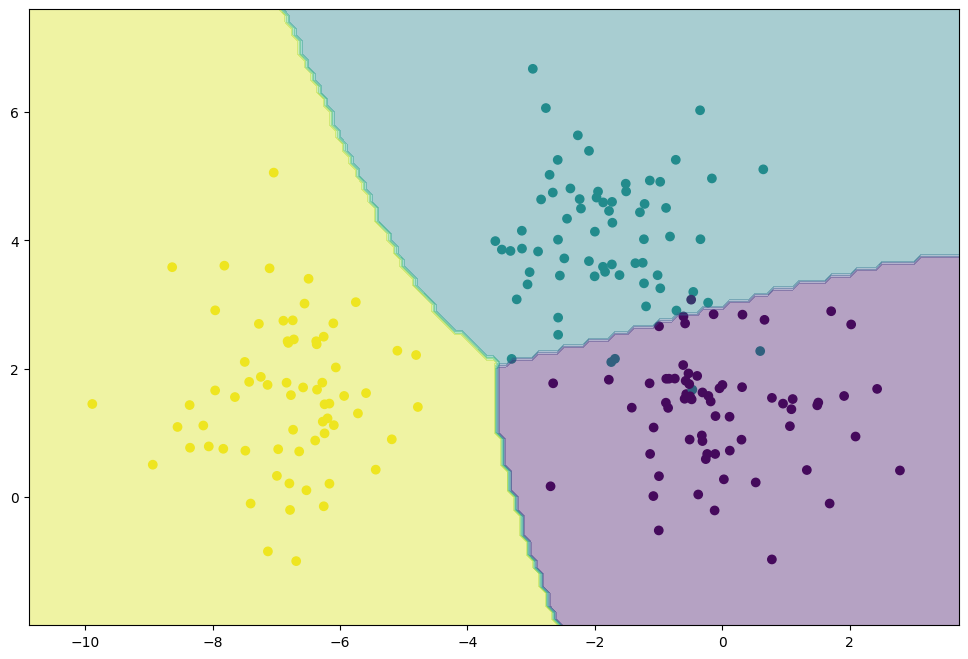

In [7]:
draw_boundary_multiclass(mlp, inputs, labels)

## Pokus na *winequality-white.csv* datasetu

In [8]:
data = pd.read_csv("winequality-white.csv", delimiter=';')
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [9]:
data["quality"].replace({3: 5, 4: 5, 8: 7, 9: 7}, inplace=True)
data["quality"].replace({5: 0, 6: 1, 7: 2}, inplace=True)

labels = data["quality"].values
inputs = data.drop(columns="quality").values

In [10]:
k = 100
mlp = MultiLayerPerceptron([inputs.shape[1], k, len(np.unique(labels))])

predictions = mlp.predict(inputs)
predicted_classes = np.argmax(predictions, axis=-1)
model_accuracy = accuracy_score(predicted_classes, labels)
print("Accuracy before training:", model_accuracy)

mlp.fit(inputs, labels)

predictions = mlp.predict(inputs)
predicted_classes = np.argmax(predictions, axis=-1)
model_accuracy = accuracy_score(predicted_classes, labels)
print("Accuracy after training:", model_accuracy)

Accuracy before training: 0.21641486320947326


Accuracy after iteration 9900: 0.4134340547162107: 100%|██████████| 10000/10000 [18:38<00:00,  8.94it/s]

Accuracy after training: 0.4156798693344222


[[1491    0  149]
 [1594    0  604]
 [ 515    0  545]]


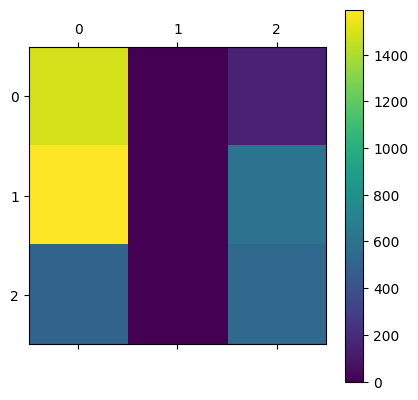

In [11]:
confusion_matrix = metrics.confusion_matrix(labels, predicted_classes)
print(confusion_matrix)

pl.matshow(confusion_matrix)
pl.colorbar()
pl.show()